# HW2 - Part 2 Template Attack
## Eyal Rechef - 213099468, Alon Abudraham - 324231992

### 1. Modifying the C code

Basically for our template attack we would want to change keys frequently, so we'll have to add a command to switch the key frequently,

For maximum flexibility, we'll just add a command for chaning the key:

```C
#include "aes-independant.h"
#include "hal.h"
#include "simpleserial.h"
#include <stdint.h>
#include <stdlib.h>

uint8_t get_pt(uint8_t *pt, uint8_t len)
{
	// Same exact function as in the attacked binary
	aes_indep_enc_pretrigger(pt);

	trigger_high();
	aes_indep_enc(pt);
	trigger_low();

	aes_indep_enc_posttrigger(pt);

	simpleserial_put('r', KEY_LENGTH, pt);
	return 0x00;
}

uint8_t get_key(uint8_t *pt, uint8_t len)
{
	// Sets the key - for acquiring traces
	aes_indep_key(pt);

	return 0x00;
}

int main(void)
{
	uint8_t secret_key[KEY_LENGTH] = {DEFAULT_KEY};

	platform_init();
	init_uart();
	trigger_setup();

	aes_indep_init();
	aes_indep_key(secret_key); // sets the key. size = 16 bytes

	simpleserial_init();
	simpleserial_addcmd('p', KEY_LENGTH, get_pt);
	simpleserial_addcmd('k', KEY_LENGTH, get_key);
	while (1)
		simpleserial_get();
}
```


### Compiling our C code
Our C firmware for the STM target is found in this directory under the name `chipwhisperer_hw2_template.c`

First we will just compile the C firwmare for the target, there is a simple bash script here which calls the `makefile`:

In [1]:
%%bash
make PLATFORM=CWLITEARM SOURCE=chipwhisperer_hw2_template.c

No CRYPTO_TARGET passed - defaulting to TINYAES128C
Building for platform CWLITEARM with CRYPTO_TARGET=TINYAES128C
SS_VER set to SS_VER_1_1
SS_VER set to SS_VER_1_1
Blank crypto options, building for AES128
.
Welcome to another exciting ChipWhisperer target build!!
arm-none-eabi-gcc (15:10.3-2021.07-4) 10.3.1 20210621 (release)
Copyright (C) 2020 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

mkdir -p objdir-CWLITEARM 
.
Compiling:
-en     chipwhisperer_hw2_template.c ...
-e Done!
.
Compiling:
-en     ../../../../firmware/mcu/simpleserial/simpleserial.c ...
-e Done!
.
Compiling:
-en     ../../../../firmware/mcu/hal/hal.c ...
-e Done!
.
Compiling:
-en     ../../../../firmware/mcu/hal//stm32f3/stm32f3_hal.c ...
-e Done!
.
Compiling:
-en     ../../../../firmware/mcu/hal//stm32f3/stm32f3_hal_lowlevel.c ...
-e Done!
.
Compiling:
-en     ../../../../firmware

## Simple imports and setting up the CW handler
We've added a simple object to make life easier for us: 

In [2]:
import chipwhisperer as cw
import numpy as np
import time
import matplotlib.pyplot as plt
from tqdm.notebook import trange
from random import randbytes


def normalize_trace(trace):
    return trace - np.mean(trace)


class CWHandler:
    DEFAULT_FIRMWARE_HEX = "output-CWLITEARM.hex"
    TARGET_CMD_OPCODE = "p"
    AES_BLOCK_SIZE = 128
    AES_BLOCK_SIZE_BYTES = AES_BLOCK_SIZE // 8

    def __init__(self, adc_samples_num: int):
        """
        Initializes a CWHandler object
        Args:
            adc_samples_num (int): Number of sampmles within a
            trace outputed by the Chip Whisperer
        """
        self.scope = cw.scope()
        self.target = cw.target(self.scope, cw.targets.SimpleSerial)
        self.scope.default_setup()
        self.scope.adc.samples = adc_samples_num

    def __del__(self):
        self.scope.dis()
        self.target.dis()

    def program_target(self, hex_file: str):
        """
        Programs the STM32 target on the Chip Whisperer
        Args:
            hex_file (str): hex_file
        """
        cw.program_target(self.scope, cw.programmers.STM32FProgrammer, hex_file)

    def program_with_our_code(self):
        self.program_target(CWHandler.DEFAULT_FIRMWARE_HEX)

    def send_command(self, opcode: str, payload: bytes):
        self.target.flush()
        self.target.simpleserial_write(opcode, payload)
        ret = self.scope.capture()
        if ret:
            raise Exception("Error in capturing response from command")
        return ret

    def encrypt_and_capture_trace(self, plaintext: bytes, key: bytes) -> np.ndarray:
        self.target.flush()
        self.scope.arm()

        assert len(plaintext) == CWHandler.AES_BLOCK_SIZE_BYTES
        assert len(key) == CWHandler.AES_BLOCK_SIZE_BYTES

        self.target.simpleserial_write("k", key)

        time.sleep(0.05)
        self.target.simpleserial_write(CWHandler.TARGET_CMD_OPCODE, plaintext)

        ret = self.scope.capture()
        if ret:
            raise Exception("Error in capturing response from command")

        trace = self.scope.get_last_trace()
        response = self.target.simpleserial_read("r", CWHandler.AES_BLOCK_SIZE_BYTES)
        return response, normalize_trace(trace)

    def encrypt_and_capture_data_with_fixed_key(self, plaintext: bytes) -> np.ndarray:
        self.target.flush()
        self.scope.arm()

        assert len(plaintext) == CWHandler.AES_BLOCK_SIZE_BYTES

        self.target.simpleserial_write(CWHandler.TARGET_CMD_OPCODE, plaintext)

        ret = self.scope.capture()
        if ret:
            raise Exception("Error in capturing response from command")

        trace = self.scope.get_last_trace()
        response = self.target.simpleserial_read("r", CWHandler.AES_BLOCK_SIZE_BYTES)
        return response, normalize_trace(trace)

c:\Users\eyalr\ChipWhisperer\chipwhisperer\jupyter\.venv\Lib\site-packages\chipwhisperer\capture\trace\TraceWhisperer.py:31: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources # type: ignore


Let's create a instance of our `CWHandler` - and program the target

In [ ]:
ADC_SAMPLE_NUM = 5000

handler = CWHandler(ADC_SAMPLE_NUM)

handler.program_with_our_code()

scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 2187699                   to 15566305                 
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.clkgen_div                   changed from 1                         to 26                       
scope.clock.clkgen_freq                  changed from 192000000.0               to 7384615.384615385        
scope.io.tio1      

### 2. Developing the strategy
Our strategy will be to run with a large dataset (>10000), in which we randomize the key and the plaintext each time.

We'll use Hamming weight (9 templates) for our attack, and hence, we'll need 5k-20k traces...

The traces then would be grouped based on their key and plaintext:

$$
Y = SBOX(HW(X \oplus K))
$$

$Y$ Would be the value which we'll group the traces according to, of course we have 16 $Y$-s, one for each key.


### 3. Capturing the traces

Let us write a simple python script to capture the traces needed:


In [ ]:
TRAIN_TRACES_NUM = 30000
MAX_SAMPLES = 5000


def get_average_trace_for_random_key_with_random_data() -> np.ndarray:
    key = randbytes(CWHandler.AES_BLOCK_SIZE_BYTES)
    text = randbytes(CWHandler.AES_BLOCK_SIZE_BYTES)
    _, trace = handler.encrypt_and_capture_trace(text, key)
    return key, text, trace


class PowerTraces:
    def __init__(self, file_prefix: str = None, trace_num: int = TRAIN_TRACES_NUM):
        """
        Initializes a PowerTraces object.
        If given files - loads from files, else - collects power traces.
        """
        if file_prefix:
            self.power_traces = np.load(f"{file_prefix}_traces.npy")
            self.keys = np.load(f"{file_prefix}_keys.npy").tolist()
            self.texts = np.load(f"{file_prefix}_texts.npy").tolist()
        else:
            self.power_traces = np.zeros((trace_num, MAX_SAMPLES))
            self.keys = []
            self.texts = []
            self.collect_power_traces(trace_num)

    def collect_power_traces(self: int, trace_num: int):
        for i in trange(trace_num):
            key, text, self.power_traces[i] = (
                get_average_trace_for_random_key_with_random_data()
            )
            self.keys.append(key)
            self.texts.append(text)

    def save(self, file_prefix: str):
        np.save(f"{file_prefix}_traces.npy", self.power_traces)
        np.save(f"{file_prefix}_keys.npy", self.keys)
        np.save(f"{file_prefix}_texts.npy", self.texts)


pt = PowerTraces()
pt.save("working_traces_2")

  0%|          | 0/30000 [00:00<?, ?it/s]

#### Sorting the Traces

As we said, we are going to group the traces according to:

$$
Y = SBOX(HW(X \oplus Y))
$$

Let us write simple code which does exactly that:

In [7]:
AES_SBOX = (
    0x63,
    0x7C,
    0x77,
    0x7B,
    0xF2,
    0x6B,
    0x6F,
    0xC5,
    0x30,
    0x01,
    0x67,
    0x2B,
    0xFE,
    0xD7,
    0xAB,
    0x76,
    0xCA,
    0x82,
    0xC9,
    0x7D,
    0xFA,
    0x59,
    0x47,
    0xF0,
    0xAD,
    0xD4,
    0xA2,
    0xAF,
    0x9C,
    0xA4,
    0x72,
    0xC0,
    0xB7,
    0xFD,
    0x93,
    0x26,
    0x36,
    0x3F,
    0xF7,
    0xCC,
    0x34,
    0xA5,
    0xE5,
    0xF1,
    0x71,
    0xD8,
    0x31,
    0x15,
    0x04,
    0xC7,
    0x23,
    0xC3,
    0x18,
    0x96,
    0x05,
    0x9A,
    0x07,
    0x12,
    0x80,
    0xE2,
    0xEB,
    0x27,
    0xB2,
    0x75,
    0x09,
    0x83,
    0x2C,
    0x1A,
    0x1B,
    0x6E,
    0x5A,
    0xA0,
    0x52,
    0x3B,
    0xD6,
    0xB3,
    0x29,
    0xE3,
    0x2F,
    0x84,
    0x53,
    0xD1,
    0x00,
    0xED,
    0x20,
    0xFC,
    0xB1,
    0x5B,
    0x6A,
    0xCB,
    0xBE,
    0x39,
    0x4A,
    0x4C,
    0x58,
    0xCF,
    0xD0,
    0xEF,
    0xAA,
    0xFB,
    0x43,
    0x4D,
    0x33,
    0x85,
    0x45,
    0xF9,
    0x02,
    0x7F,
    0x50,
    0x3C,
    0x9F,
    0xA8,
    0x51,
    0xA3,
    0x40,
    0x8F,
    0x92,
    0x9D,
    0x38,
    0xF5,
    0xBC,
    0xB6,
    0xDA,
    0x21,
    0x10,
    0xFF,
    0xF3,
    0xD2,
    0xCD,
    0x0C,
    0x13,
    0xEC,
    0x5F,
    0x97,
    0x44,
    0x17,
    0xC4,
    0xA7,
    0x7E,
    0x3D,
    0x64,
    0x5D,
    0x19,
    0x73,
    0x60,
    0x81,
    0x4F,
    0xDC,
    0x22,
    0x2A,
    0x90,
    0x88,
    0x46,
    0xEE,
    0xB8,
    0x14,
    0xDE,
    0x5E,
    0x0B,
    0xDB,
    0xE0,
    0x32,
    0x3A,
    0x0A,
    0x49,
    0x06,
    0x24,
    0x5C,
    0xC2,
    0xD3,
    0xAC,
    0x62,
    0x91,
    0x95,
    0xE4,
    0x79,
    0xE7,
    0xC8,
    0x37,
    0x6D,
    0x8D,
    0xD5,
    0x4E,
    0xA9,
    0x6C,
    0x56,
    0xF4,
    0xEA,
    0x65,
    0x7A,
    0xAE,
    0x08,
    0xBA,
    0x78,
    0x25,
    0x2E,
    0x1C,
    0xA6,
    0xB4,
    0xC6,
    0xE8,
    0xDD,
    0x74,
    0x1F,
    0x4B,
    0xBD,
    0x8B,
    0x8A,
    0x70,
    0x3E,
    0xB5,
    0x66,
    0x48,
    0x03,
    0xF6,
    0x0E,
    0x61,
    0x35,
    0x57,
    0xB9,
    0x86,
    0xC1,
    0x1D,
    0x9E,
    0xE1,
    0xF8,
    0x98,
    0x11,
    0x69,
    0xD9,
    0x8E,
    0x94,
    0x9B,
    0x1E,
    0x87,
    0xE9,
    0xCE,
    0x55,
    0x28,
    0xDF,
    0x8C,
    0xA1,
    0x89,
    0x0D,
    0xBF,
    0xE6,
    0x42,
    0x68,
    0x41,
    0x99,
    0x2D,
    0x0F,
    0xB0,
    0x54,
    0xBB,
    0x16,
)


def hamming_weight(x: int) -> int:
    res = 0
    while x != 0:
        res += x & 1
        x >>= 1
    return res


NUMBER_OF_OPERATIONS = 9  # HW number of options


class SortedTraces:
    def __init__(self, pt: PowerTraces, byte_idx: int = 0):
        self.power_traces = pt
        self.power_traces_by_operation = [[] for _ in range(NUMBER_OF_OPERATIONS)]
        self.byte_idx = byte_idx
        self.sort_by_hw_of_sbox()

    def sort_by_hw_of_sbox(self):
        sbox_values = [
            AES_SBOX[
                self.power_traces.keys[i][self.byte_idx]
                ^ self.power_traces.texts[i][self.byte_idx]
            ]
            for i in range(len(self.power_traces.keys))
        ]
        hamming_weights = [hamming_weight(byte) for byte in sbox_values]
        for i in range(len(sbox_values)):
            self.power_traces_by_operation[hamming_weights[i]].append(
                self.power_traces.power_traces[i]
            )
        self.power_traces_by_operation = [
            np.array(traces) for traces in self.power_traces_by_operation
        ]

### 4. Identify clock cycles with the highest SNR for each key byte

Now we have lots of power traces - 
- For each byte index
    - For each option for this byte
        - Times the sample ratio (for averaging out noises)

Referring to the formula from class:

$$
M_{k, i} = \frac{1}{T_k}\sum_{j=1}^{T_k}t_{j,i}
$$

In our case $T_k=5$, $k$ is the byte sweeping from $0$ to $255$.

Then we'll calculate:

$$
D_i = \sum_{k_1, k_2}\left|M_{k_1, i} - M_{k_2, i}\right|
$$

Then our POI will be the point with the highest $D_i$.

Then when we'll have all $D$ - we can calculate the POIs by finding the highest point of $D_i$.
To find few POIs:

- Pick the highest point in $D_i$ and save this as the $n$-th POI
- Throw out the nearest $N$ points
- Repeat until enough POIs have been selected

We'll use 5 POIs as the exercise requested.

Let us write the python code which extracts these POIs.

In [ ]:
NUM_OF_POIS = 5
MIN_POI_SPACING = 5


class PoiHandler:
    def __init__(self, sorted_traces: SortedTraces, poi_number: int, poi_spacing: int):
        self.sorted_traces = sorted_traces
        self.mean_vectors = self.get_average_power_traces()
        self.diff_vectors = self.get_diff_vector()
        self.pois = self.extract_poi_from_diff_vector(poi_number, poi_spacing)

    def get_average_power_traces(self):
        return [
            np.average(self.sorted_traces.power_traces_by_operation[i], 0)
            for i in range(NUMBER_OF_OPERATIONS)
        ]

    def get_diff_vector(self) -> np.ndarray:
        d = np.zeros((ADC_SAMPLE_NUM))
        for k1 in range(NUMBER_OF_OPERATIONS):
            for k2 in range(NUMBER_OF_OPERATIONS):
                d += np.abs(self.mean_vectors[k1] - self.mean_vectors[k2])

        return d

    def extract_poi_from_diff_vector(self, num_of_pois: int, min_poi_spacing: int):
        pois = []
        for _ in range(num_of_pois):
            curr_poi = np.argmax(self.diff_vectors)
            pois.append(curr_poi)
            self.diff_vectors[
                curr_poi - min_poi_spacing : curr_poi + min_poi_spacing
            ] = 0

        return pois

Now we have the POIs for each key byte (5 for each).

### 5. Characterize the leakage by estimating PDFs for different key values
For each key byte, we'll generate a probability density function (PDF) for the leakage at its POIs.

1. Grouping by Operation
    - We already have all the power traces that fall under "operation $k$", these are just the power traces taken for a specific byte value
    - Then we extract the POIs from these to create a Data Matrix for operation $k$: $\{ t_{j,s_i} \}_{j=1\dots T_k,i=1\dots I}$ where $T_k$ is the trace redundancy and $I$ is the number of POIs.

2. Mean Vector Estimation
    - We'll compute average leakage at each POI for operation $k$ - $\mu_i = \sum_{j=1}^{T_k}t_{j,s_i}$
    - Builds the mean vector - $\mu_k = [\mu_1\ \mu_2\ \dots\ \mu_I]^T$

3. Variance & Covariance Estimation
    - Now we can calculate variance for each POI - $v_i=\frac{1}{T_k}\sum_{j=1}^{T_k}(t_{j,s_i}-\mu_i)^2$
    - And the covariance for every pair of POIs - $c_{i,i^*}=\frac{1}{T_k}\sum_{j=1}^{T_k}(t_{j,s_i}-\mu_i)(t_{j,s_{i^*}}-\mu_{i^*})$
    - Put these into a covariance matrix: $\Sigma_k = 
\begin{bmatrix}
v_1 & c_{1,2} & c_{1,3} & \cdots \\
c_{2,1} & v_2 & c_{2,3} & \cdots \\
c_{3,1} & c_{3,2} & v_3 & \cdots \\
\vdots & \vdots & \vdots & \ddots
\end{bmatrix}$

4. Template Definition
    - Now we can create a template (PDF) for each operation $k$, and a vector $x$ of power samples in its POIs:

    $$
    f_k(x)=\frac{1}{\sqrt{(2\pi)^I\left|\Sigma_k\right|}}e^{-\frac{1}{2}(x-\mu_k)^T(\Sigma_k)^{-1}(x-\mu_k)}
    $$

  0%|          | 0/16 [00:00<?, ?it/s]

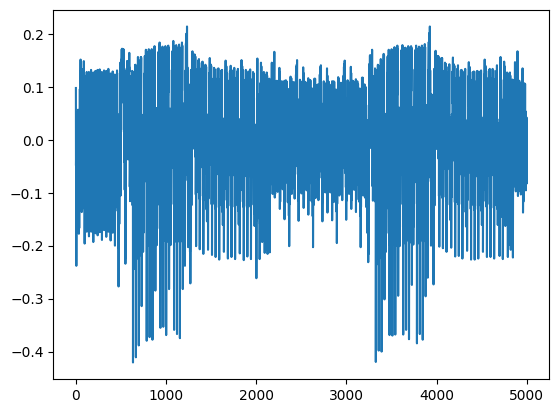

In [9]:
from scipy.stats import multivariate_normal


class Template:
    def __init__(self, poi: PoiHandler):
        self.poi = poi
        self.mean_matrix = np.zeros((NUMBER_OF_OPERATIONS, NUM_OF_POIS))
        self.cov_matrices = np.zeros((NUMBER_OF_OPERATIONS, NUM_OF_POIS, NUM_OF_POIS))
        self.normal_dist = []
        self.get_template_parameters()

    def calc_mean_matrix(self):
        for operation in range(NUMBER_OF_OPERATIONS):
            for poi_idx in range(NUM_OF_POIS):
                self.mean_matrix[operation][poi_idx] = self.poi.mean_vectors[operation][
                    self.poi.pois[poi_idx]
                ]

    def calc_cov_matrices(self):
        for op in range(NUMBER_OF_OPERATIONS):
            for i in range(NUM_OF_POIS):
                for j in range(NUM_OF_POIS):
                    self.cov_matrices[op][i][j] = np.cov(
                        np.array(
                            self.poi.sorted_traces.power_traces_by_operation[op][
                                :, self.poi.pois[i]
                            ]
                        ),
                        np.array(
                            self.poi.sorted_traces.power_traces_by_operation[op][
                                :, self.poi.pois[j]
                            ]
                        ),
                    )[0][1]

    def get_template_parameters(self):
        self.calc_mean_matrix()
        self.calc_cov_matrices()
        for i in range(NUMBER_OF_OPERATIONS):
            self.normal_dist.append(
                multivariate_normal(mean=self.mean_matrix[i], cov=self.cov_matrices[i])
            )


templates = []


traces = PowerTraces("working_traces_2")

for idx in range(len(traces.texts)):
    if len(traces.texts[idx]) < CWHandler.AES_BLOCK_SIZE_BYTES:
        traces.texts[idx] += b"\x00" * (
            CWHandler.AES_BLOCK_SIZE_BYTES - len(traces.texts[idx])
        )
    if len(traces.keys[idx]) < CWHandler.AES_BLOCK_SIZE_BYTES:
        traces.keys[idx] += b"\x00" * (
            CWHandler.AES_BLOCK_SIZE_BYTES - len(traces.keys[idx])
        )


plt.plot(traces.power_traces[0])
for i in trange(CWHandler.AES_BLOCK_SIZE_BYTES):
    sorted_traces = SortedTraces(traces, i)
    poi_handler = PoiHandler(
        sorted_traces, poi_number=NUM_OF_POIS, poi_spacing=MIN_POI_SPACING
    )
    templates.append(Template(poi_handler))

### 6. Performing the Attack

Now we have our templates, time to deploy our attack!

The flow for the attack:

- Capture 50 traces (max amount recommended in class), with random plaintexts - and the same secret key we wish to recover
- For each trace - and for each key byte (0-15), we'll run over all the possible byte values (0-255) and calculate the hypothesis for $SBOX(HW(X\oplus Y))$
- For each byte hypothesis, we'll check the PDF of the normal distribution from the template (at the POIs of the function):
$$
p_{k,j} = f_k(a_j)
$$
- Then after doing it for all traces, we could combine the likelihoods using the Log-Sum trick
$$
\ell_k = \log P_k = \sum_{j=1}^{A} \log p_{k,j}
$$

Then we could say that our hypothesis for the current byte is $k^* = \argmax_{k}(\ell_k)$

Doing it to every byte in the key, would reveal use the full key.

In [183]:
const_key = randbytes(CWHandler.AES_BLOCK_SIZE_BYTES)


def get_average_trace_for_fixed_key_with_random_data():
    text = randbytes(CWHandler.AES_BLOCK_SIZE_BYTES)
    _, trace = handler.encrypt_and_capture_trace(text, const_key)
    return text, trace


KEY_OPTIONS = 2**8
ATTACK_TRACE_NUM = 50


class Attack:
    def __init__(
        self,
        templates: list[Template],
        trace_num: int,
        get_text_and_trace_callback,
    ):
        self.templates = templates
        self.trace_num = trace_num
        self.get_text_and_trace_callback = get_text_and_trace_callback
        self.texts = []
        self.traces = []
        self.key_guesses = []
        self.key_probe_likelihood_history = np.zeros(
            (len(self.templates), KEY_OPTIONS, self.trace_num)
        )

    def capture_attack_traces(self):
        for _ in trange(self.trace_num):
            text, trace = self.get_text_and_trace_callback()
            self.texts.append(text)
            self.traces.append(trace)

    def perform_attack(self):
        extracted_key = bytearray(bytes(len(self.templates)))
        for idx, template in enumerate(self.templates):
            extracted_key[idx] = self.perform_attack_single_template(idx, template)[-1]
        return extracted_key

    def perform_attack_single_template(self, idx: int, template: Template) -> int:
        key_guesses = []
        key_prob = np.zeros(KEY_OPTIONS)
        for i in range(self.trace_num):
            trace_pois = self.traces[i][template.poi.pois]
            for k in range(KEY_OPTIONS):
                hw = hamming_weight(AES_SBOX[self.texts[i][idx] ^ k])
                key_prob[k] += np.log(template.normal_dist[hw].pdf(trace_pois))
                self.key_probe_likelihood_history[idx][k][i] = key_prob[k]
            key_guesses.append(np.argmax(key_prob))
        self.key_guesses.append(key_guesses)
        return key_guesses


attack = Attack(
    templates,
    trace_num=ATTACK_TRACE_NUM,
    get_text_and_trace_callback=get_average_trace_for_fixed_key_with_random_data,
)

attack.capture_attack_traces()
key = attack.perform_attack()

print(bytearray(const_key))
print(key)

  0%|          | 0/50 [00:00<?, ?it/s]

bytearray(b'H\xbb\x01\x92\xe1Xj\xfb\xed\x08\xff\xc7\xe2x\xba3')
bytearray(b'H\xbb\x01\x92\xe1Xj\xfb\xed\x08\xff\xc7\xe2x\xba3')


And we indeed got the same keys! Now it is time to move the target executable (already stores the key), let us program it into the device: 

We tried to run with Yahav's C code, but unfortunately, it did not yield great results... Even after trying to normalize the traces...

We tried to research it but did not found a reason why, so we modified it to be like our C code, which then brought good results.

In [181]:
%%bash
make PLATFORM=CWLITEARM SOURCE=simpleserial-aes-with-key.c

No CRYPTO_TARGET passed - defaulting to TINYAES128C
Building for platform CWLITEARM with CRYPTO_TARGET=TINYAES128C
SS_VER set to SS_VER_1_1
SS_VER set to SS_VER_1_1
Blank crypto options, building for AES128
.
Welcome to another exciting ChipWhisperer target build!!
arm-none-eabi-gcc (15:10.3-2021.07-4) 10.3.1 20210621 (release)
Copyright (C) 2020 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

mkdir -p objdir-CWLITEARM 
.
Compiling:
-en     simpleserial-aes-with-key.c ...
-e Done!
.
Compiling:
-en     ../../../../firmware/mcu/simpleserial/simpleserial.c ...
-e Done!
.
Compiling:
-en     ../../../../firmware/mcu/hal/hal.c ...
-e Done!
.
Compiling:
-en     ../../../../firmware/mcu/hal//stm32f3/stm32f3_hal.c ...
-e Done!
.
Compiling:
-en     ../../../../firmware/mcu/hal//stm32f3/stm32f3_hal_lowlevel.c ...
-e Done!
.
Compiling:
-en     ../../../../firmware/

In [19]:
handler.program_with_our_code()

Detected known STMF32: STM32F302xB(C)/303xB(C)
Extended erase (0x44), this can take ten seconds or more
Attempting to program 6171 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 6171 bytes


In [50]:
def get_trace_from_unknown_target():
    text = randbytes(CWHandler.AES_BLOCK_SIZE_BYTES)
    _, trace = handler.encrypt_and_capture_data_with_fixed_key(text)
    return text, trace


attack_2 = Attack(
    templates,
    trace_num=ATTACK_TRACE_NUM,
    get_text_and_trace_callback=get_trace_from_unknown_target,
)

attack_2.capture_attack_traces()
key = attack_2.perform_attack()

print(key)

  0%|          | 0/50 [00:00<?, ?it/s]

bytearray(b'This is Correct!')


And this is indeed the key - 'This is Correct!.

### Required Submittions - Graphs

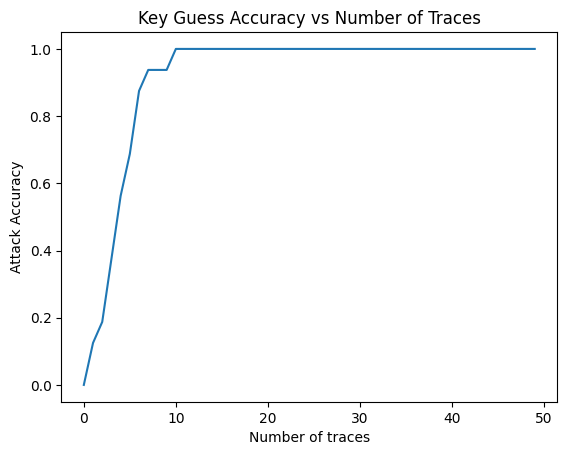

In [184]:
from scipy.stats import norm

expected_key: bytes = b"This is Correct!"

BINOMIAL_PROBABILITIES_HW = [
    1 / 256,
    8 / 256,
    28 / 256,
    56 / 256,
    70 / 256,
    56 / 256,
    28 / 256,
    8 / 256,
    1 / 256,
]


class AttackWithGraphs:
    def __init__(self, attack: Attack):
        self.templates = attack.templates
        self.texts = attack.texts
        self.traces = attack.traces
        self.key_guesses = attack.key_guesses
        self.key_probe_likelihood_history = attack.key_probe_likelihood_history
        self.templates = attack.templates

    def produce_key_guess_accuracy_vec(self, expected_key):
        guessed_key_per_iteration = self.get_guessed_key_per_iteration()
        accuracy = np.zeros(len(self.traces))
        for i in range(len(self.traces)):
            curr_accuracy = 0
            for j in range(CWHandler.AES_BLOCK_SIZE_BYTES):
                if guessed_key_per_iteration[i][j] == expected_key[j]:
                    curr_accuracy += 1
            accuracy[i] = curr_accuracy / CWHandler.AES_BLOCK_SIZE_BYTES
        plt.plot(accuracy)
        plt.xlabel("Number of traces")
        plt.ylabel("Attack Accuracy")
        plt.title("Key Guess Accuracy vs Number of Traces")

    def get_guessed_key_per_iteration(self):
        guessed_key_per_iteration = []
        for i in range(len(self.traces)):
            key = bytearray(bytes(CWHandler.AES_BLOCK_SIZE_BYTES))
            for j in range(CWHandler.AES_BLOCK_SIZE_BYTES):
                key[j] = self.key_guesses[j][i]
            guessed_key_per_iteration.append(key)
        return guessed_key_per_iteration

    def get_correct_key_likelihood_vs_trace_count(self, byte_idx: int, byte_value: int):
        plt.plot(self.key_probe_likelihood_history[byte_idx][byte_value])
        plt.xlabel("Number of traces")
        plt.ylabel("Likelihood")
        plt.title(f"Likelihood of Correct Key Byte {byte_idx} being {byte_value}")
        plt.show()

    def get_leakage_at_pois_vs_key_values(self, byte_idx: int):
        for poi_idx in range(NUM_OF_POIS):
            leakages_at_poi_vs_hw = [[] for _ in range(NUMBER_OF_OPERATIONS)]
            for i in range(len(self.traces)):
                current_class = hamming_weight(
                    AES_SBOX[self.texts[i][byte_idx] ^ expected_key[byte_idx]]
                )
                leakages_at_poi_vs_hw[current_class].append(
                    self.traces[i][self.templates[current_class].poi.pois[poi_idx]]
                )
            for i in range(NUMBER_OF_OPERATIONS):
                leakages_at_poi_vs_hw[i] = (
                    np.mean(leakages_at_poi_vs_hw[i]) if leakages_at_poi_vs_hw[i] else 0
                )
            plt.plot(leakages_at_poi_vs_hw)
        plt.xlabel("Hamming Weight (HW(SBOX(X XOR K)))")
        plt.ylabel("Leakage")
        plt.title(f"Leakage at POIs for Key Byte {byte_idx} vs Hamming Weight")
        plt.legend([f"POI {i}" for i in range(NUM_OF_POIS)])
        plt.show()

    def get_gmm_at_highest_snr(self, byte_idx: int):
        pdf = np.zeros(1000)
        max_snr_poi = self.calc_highest_snr_poi(byte_idx)
        print(max_snr_poi)
        for hw in range(NUMBER_OF_OPERATIONS):
            mu = self.templates[byte_idx].mean_matrix[hw][max_snr_poi]
            cov = self.templates[byte_idx].cov_matrices[hw][max_snr_poi][max_snr_poi]
            leakage_space = np.linspace(-0.05, -0.00, 1000)
            pdf += BINOMIAL_PROBABILITIES_HW[hw] * norm.pdf(leakage_space, mu, cov)
        pdf /= np.max(pdf)
        pdf *= 100
        leakages_at_poi = [
            self.traces[i][self.templates[byte_idx].poi.pois[max_snr_poi]]
            for i in range(len(self.traces))
        ]
        plt.plot(leakage_space, pdf)
        plt.hist(leakages_at_poi, density=True, bins=20)
        plt.xlabel("Leakage")
        plt.ylabel("Probability Density")
        plt.title(f"GMM for Key Byte {byte_idx}")
        plt.show()

    def calc_highest_snr_poi(self, byte_idx: int):
        poi_snrs = [self.get_snr_at_poi(i, byte_idx) for i in range(NUM_OF_POIS)]
        max_snr_idx = np.argmax(poi_snrs)
        return max_snr_idx

    def get_snr_at_poi(self, poi_idx: int, byte_idx: int):
        mus = []
        vars = []
        for trace in self.templates[
            byte_idx
        ].poi.sorted_traces.power_traces_by_operation:
            data_set = trace[:, self.templates[byte_idx].poi.pois[poi_idx]]
            mus.append(np.mean(data_set))
            vars.append(np.var(data_set))
        snr = np.var(mus) / np.mean(vars)
        return snr


attack_with_graphs = AttackWithGraphs(attack_2)
attack_with_graphs.produce_key_guess_accuracy_vec(expected_key)

As we can see, from around 15 traces our attack becomes 100% accurate.

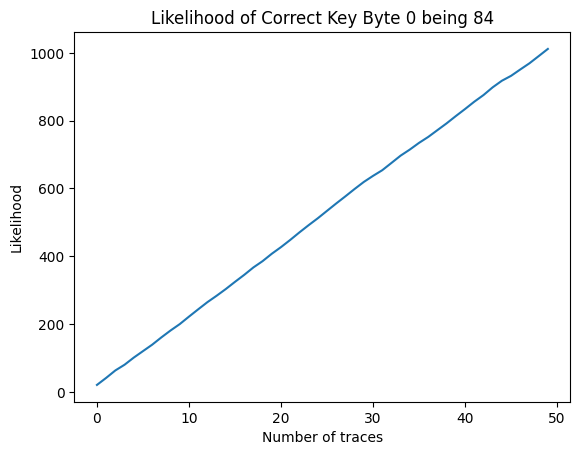

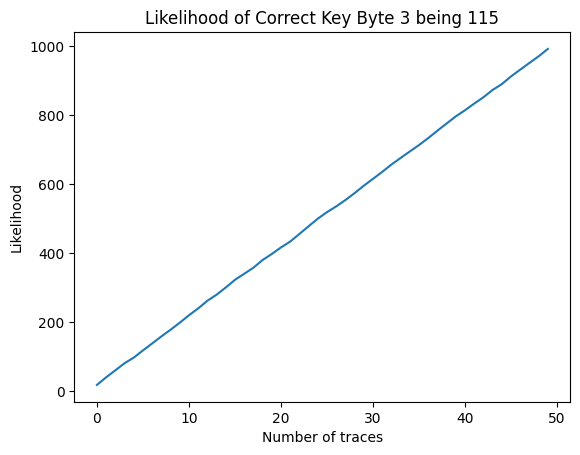

In [185]:
attack_with_graphs.get_correct_key_likelihood_vs_trace_count(0, expected_key[0])
attack_with_graphs.get_correct_key_likelihood_vs_trace_count(3, expected_key[3])

We see a linear increase in the likelihood with the traces counting, this is of course in a logarithmic scale. It makes sense that more traces gives higher likelihood for correctness in the correct key value.

We showed for example the likelihood of indices 0 and 3 of the key.

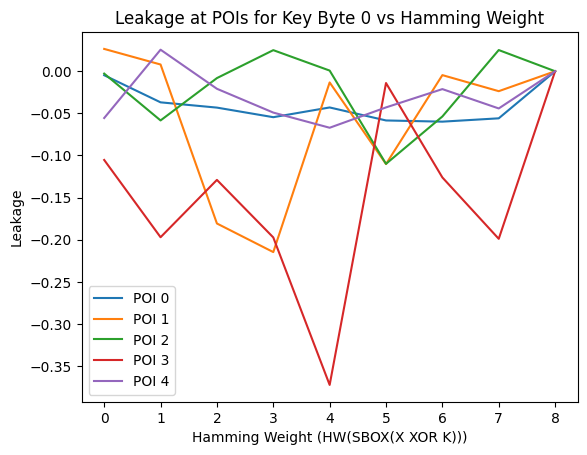

In [186]:
attack_with_graphs.get_leakage_at_pois_vs_key_values(0)

From here it seems like POI4 is the one with the highest SNR, even though it should be 0 (due to our later calculation of SNR and the fact that it was found first), probably this is due to the small dataset we used (only 50 traces).

0


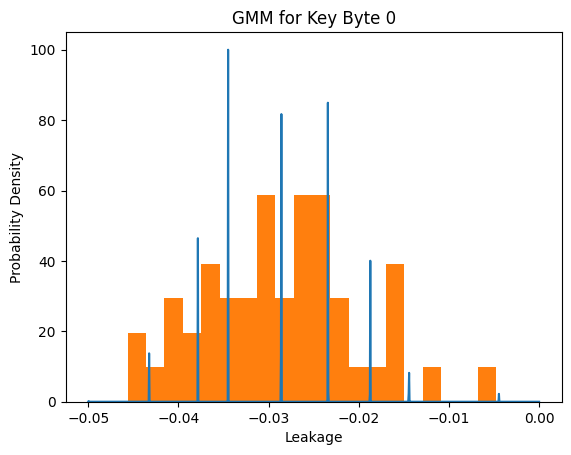

In [187]:
attack_with_graphs.get_gmm_at_highest_snr(0)

We have found that the POI with the highest SNR is 0, and we showed the GMM for all the Hamming weights, and plotted them together, still, this is not a lot of traces, but we can see the correlation between the pdfs and the histograms.

To join the PDFs into a GMM we used the binomial probabilities of each hamming weight.